---
title: "Multiple Testing"
subtitle: "A quick guide to comparing several performance measures and correcting their p-values"
---

This page is aimed at anyone who needs to compare systems on more than one performance measure at once -- e.g., precision together with recall -- rather than settling for a single score. `CompStats.interface.Perf` can hold several measures in one instance, evaluated on the same paired bootstrap distribution, so the comparisons stay consistent across measures; `Difference.p_value`'s `correction` argument then adjusts for testing several hypotheses at the same time, whether those hypotheses come from several systems, several measures, or both.

## Dataset

Three synthetic submissions are built from the same gold standard, each with a different precision/recall trade-off: `precise` predicts the positive class conservatively (few false positives, more missed positives), `broad` predicts it liberally (catches almost every positive, but with more false alarms), and `balanced` sits between the two. The trade-off is controlled directly by each system's false-positive and false-negative rates, so the example does not depend on training an actual classifier.

In [1]:
import numpy as np

def make_system(y_true, fp_rate, fn_rate, seed):
    """A synthetic system that mislabels negatives/positives at the given rates"""
    rng = np.random.default_rng(seed)
    y_pred = y_true.copy()
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    y_pred[pos_idx[rng.random(pos_idx.shape[0]) < fn_rate]] = 0
    y_pred[neg_idx[rng.random(neg_idx.shape[0]) < fp_rate]] = 1
    return y_pred

rng = np.random.default_rng(0)
y_gold = (rng.random(400) < 0.5).astype(int)
precise = make_system(y_gold, fp_rate=0.02, fn_rate=0.30, seed=1)
broad = make_system(y_gold, fp_rate=0.30, fn_rate=0.02, seed=2)
balanced = make_system(y_gold, fp_rate=0.11, fn_rate=0.13, seed=3)

## Comparing three performance measures at once

Passing a list of functions to `Perf`'s `func` argument combines them into a single, multi-measure instance -- here `precision_score`, `recall_score`, and `f1_score` from `CompStats.metrics`, each built with its `.measure` factory so its `BiB` tag (bigger is better, for all three) travels with it. `measure_names` labels the columns of the result. As with a single-measure `Perf`, fixing the seed makes the bootstrap resampling below reproducible.

In [2]:
from CompStats.metrics import precision_score, recall_score, f1_score
from CompStats.interface import Perf

np.random.seed(42)
perf = Perf(y_gold, precise=precise, broad=broad, balanced=balanced,
            func=[precision_score.measure(pos_label=1),
                  recall_score.measure(pos_label=1),
                  f1_score.measure(pos_label=1)],
            measure_names=['Precision', 'Recall', 'F1'])
perf

<Perf(func=Precision+Recall+F1)>
Statistic with its standard error (se)
statistic (se)
0.8859 (0.0245), 0.8907 (0.0239), 0.8883 (0.0190) <= balanced
0.9776 (0.0129), 0.7158 (0.0332), 0.8265 (0.0229) <= precise
0.7149 (0.0306), 0.9727 (0.0120), 0.8241 (0.0211) <= broad

## Best system per measure

`Perf.best` reports the top system for every measure, and the three systems split the wins exactly as their construction intends: `precise` leads on Precision, `broad` leads on Recall, and `balanced` -- which is not the best at either individual measure -- comes out ahead once Precision and Recall are combined into F1. Note that `best` only compares point estimates; it says nothing about whether the lead is statistically significant, which is exactly what the next section checks.

In [3]:
perf.best

array(['precise', 'broad', 'balanced'], dtype='<U8')

## p-values per measure

`Perf.difference()` still produces a `Difference` instance from the same paired bootstrap distribution, and `Difference.p_value()` now returns one array per system, with one entry per measure.

In [4]:
import pandas as pd

diff = perf.difference()
pd.DataFrame(diff.p_value(), index=perf.measure_names).T

,Precision,Recall,F1
balanced,0.0,0.004,1.000
broad,0.0,1.000,0.008
precise,1.0,0.000,0.022


`precise` and `broad` are each other's clear runner-up on the measure the other wins (Recall and Precision, respectively), with a p-value of essentially 0. The interesting row is F1: both `precise` and `broad` trail `balanced` with uncorrected p-values under 0.05 (0.022 and 0.008), so a naive reading would call `balanced` significantly ahead of both. But three measures were just tested against `balanced` at once, so before trusting that F1 conclusion, the next section checks whether it survives a correction for multiple comparisons.

## Correcting for multiple comparisons

`Difference.p_value`'s `correction` argument passes any method supported by `statsmodels.stats.multitest.multipletests` -- e.g. `'bonferroni'`, `'holm'`, `'fdr_bh'` -- and, with several measures, corrects each measure independently (i.e. per column), so one metric's correction never mixes with another's. The following table focuses on the F1 column, comparing the raw p-values against the three correction methods.

In [5]:
pd.DataFrame({
    'raw': {k: v[2] for k, v in diff.p_value().items()},
    'bonferroni': {k: v[2] for k, v in diff.p_value(correction='bonferroni').items()},
    'holm': {k: v[2] for k, v in diff.p_value(correction='holm').items()},
    'fdr_bh': {k: v[2] for k, v in diff.p_value(correction='fdr_bh').items()},
})

,raw,bonferroni,holm,fdr_bh
balanced,1.000,1.000,1.000,1.000
broad,0.008,0.024,0.024,0.024
precise,0.022,0.066,0.044,0.033


`broad` stays significantly behind `balanced` on F1 under every method. `precise`, however, crosses the 0.05 threshold depending on the correction: Bonferroni's stricter adjustment (0.066) is enough to call it statistically tied with `balanced` on F1, while Holm (0.044) and the FDR correction (0.033) both keep it significantly behind. This is the same lesson as [Competition Organizers](competition_organizers.ipynb)'s Team Gamma, except the extra hypothesis being tested here comes from combining measures rather than from ranking more systems.

## Visualizing the comparison

`Perf.plot` renders one panel per measure, coloring each system by whether it is the best, tied with the best, or significantly behind it on that measure -- so the three-way split from `perf.best` above is visible directly, alongside each system's confidence interval.

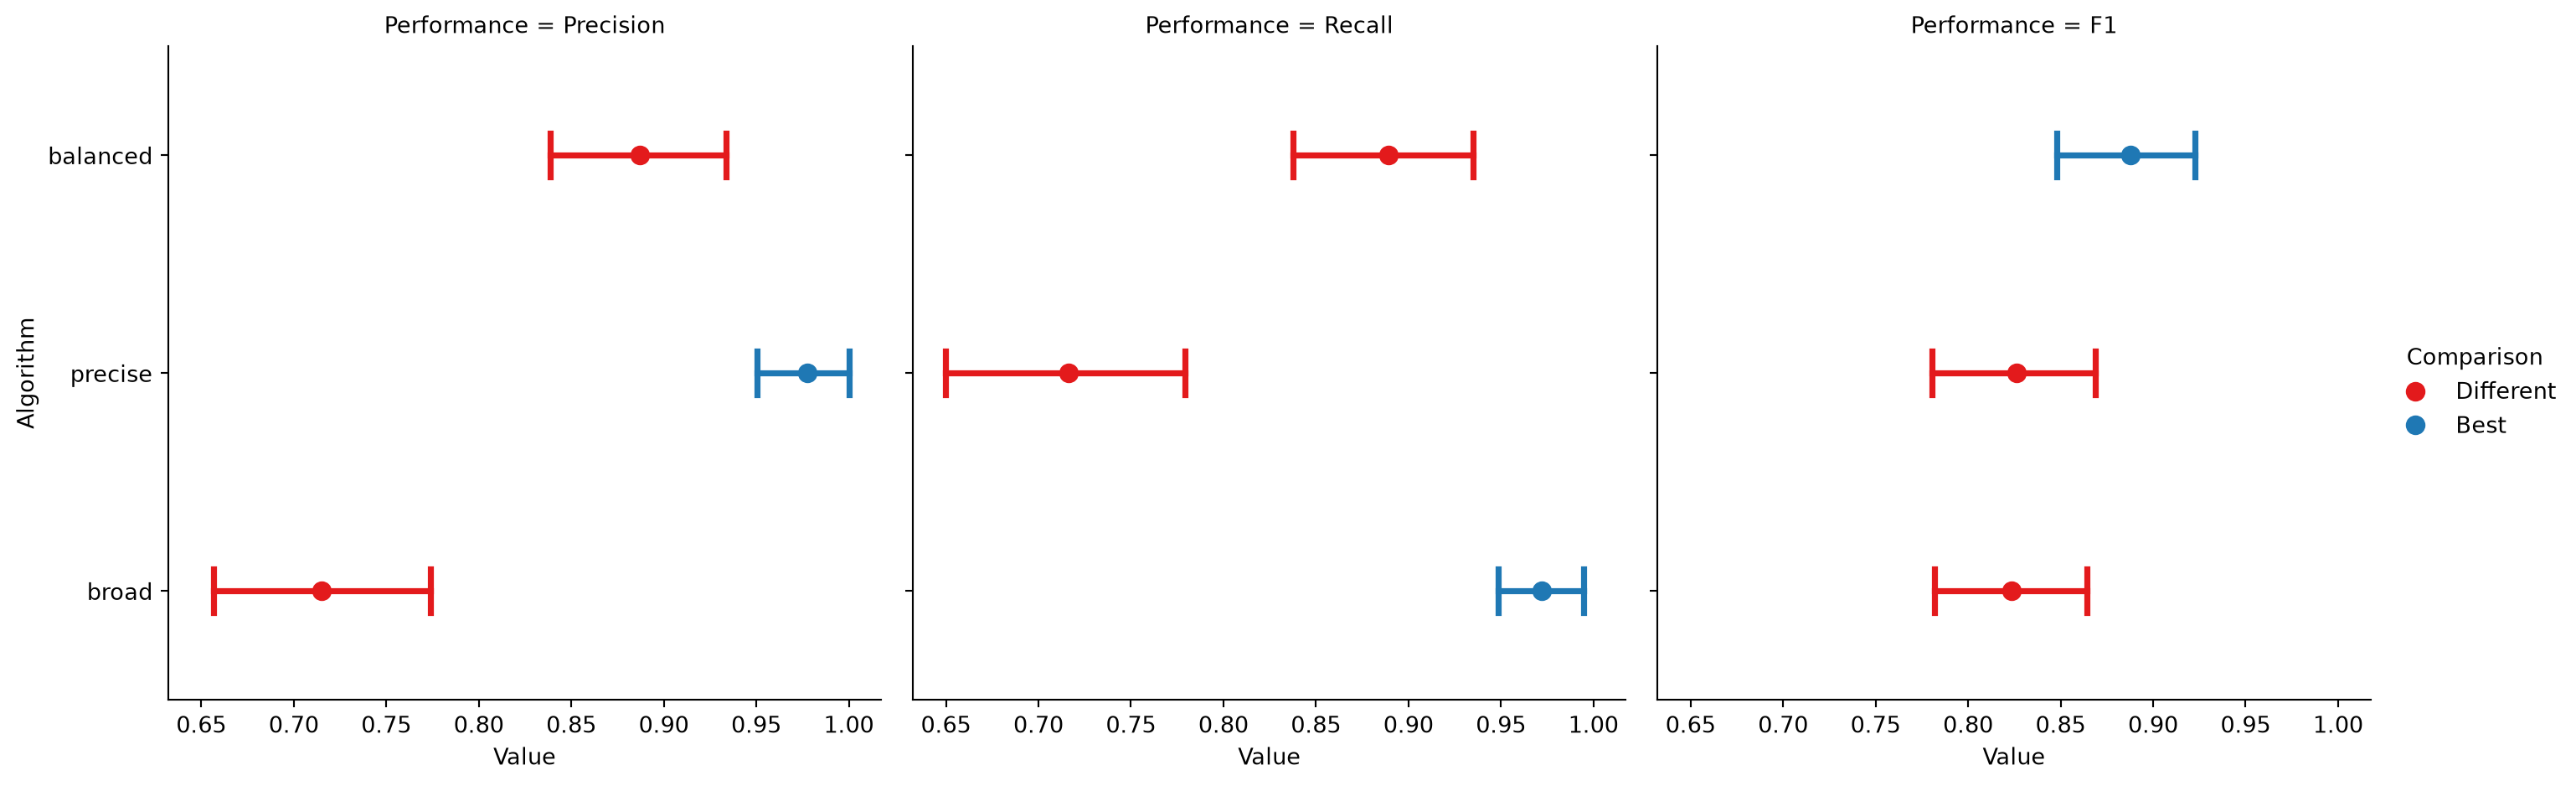

In [6]:
perf.plot()

`Difference.plot` shows the same paired differences against each measure's best system, coloring by statistical significance instead.

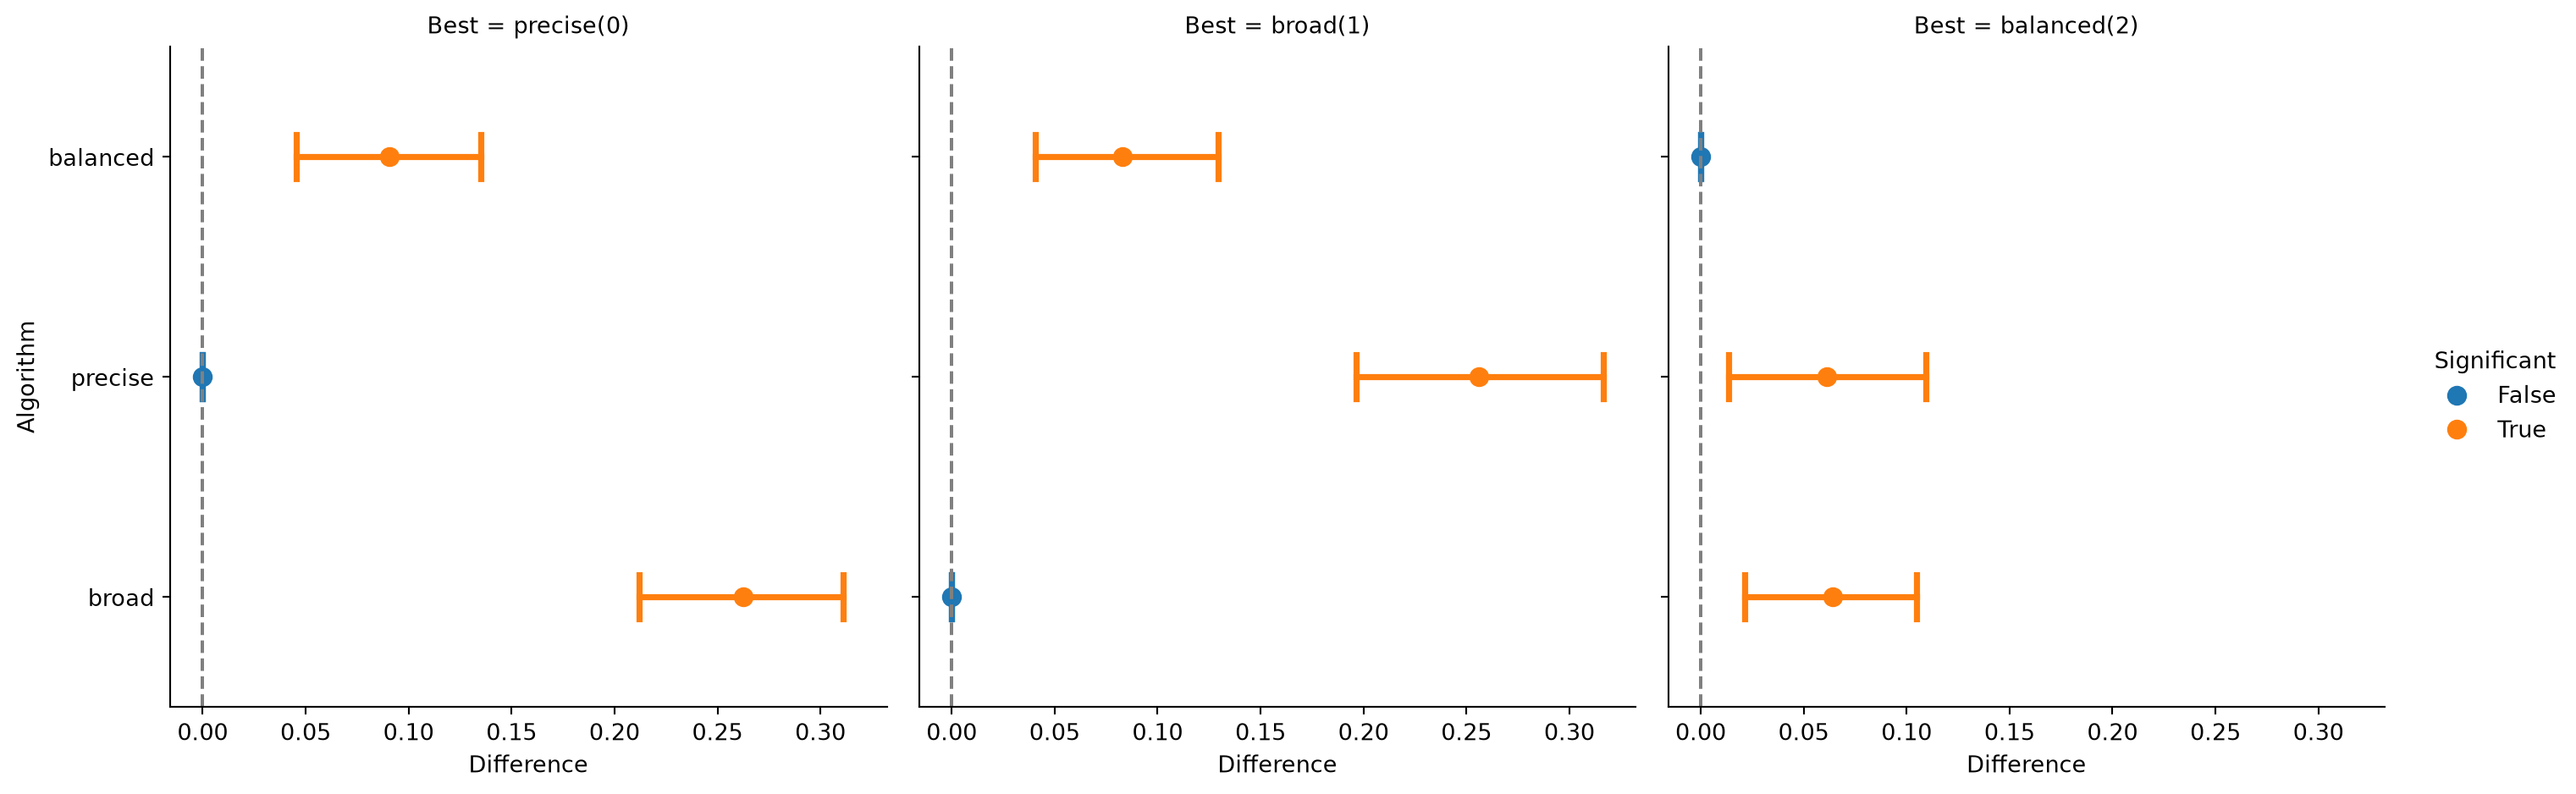

In [7]:
diff.plot()

Passing `correction='bonferroni'` recolors `precise`'s F1 panel from significantly behind to tied in both plots, matching the table above; `'holm'` and `'fdr_bh'` would leave every panel unchanged from the uncorrected plots, since neither pushes `precise`'s F1 p-value past 0.05.

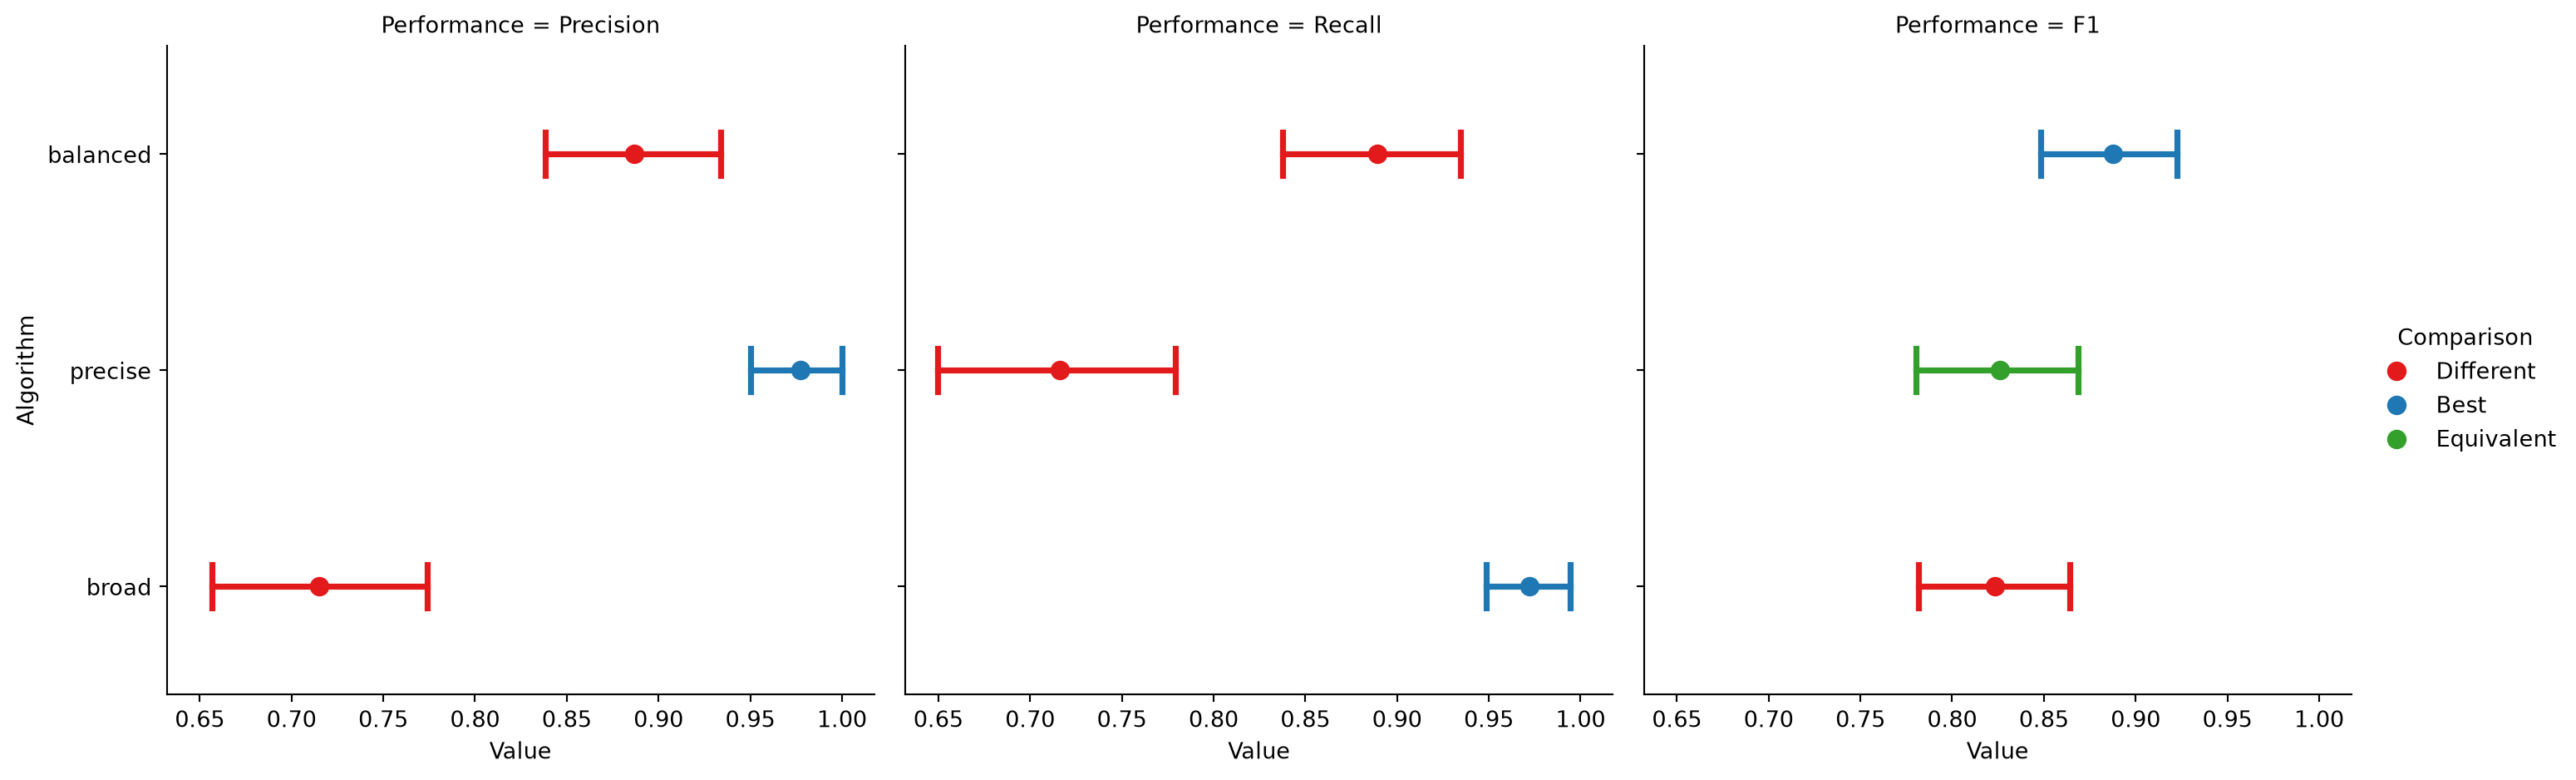

In [8]:
perf.plot(correction='bonferroni')

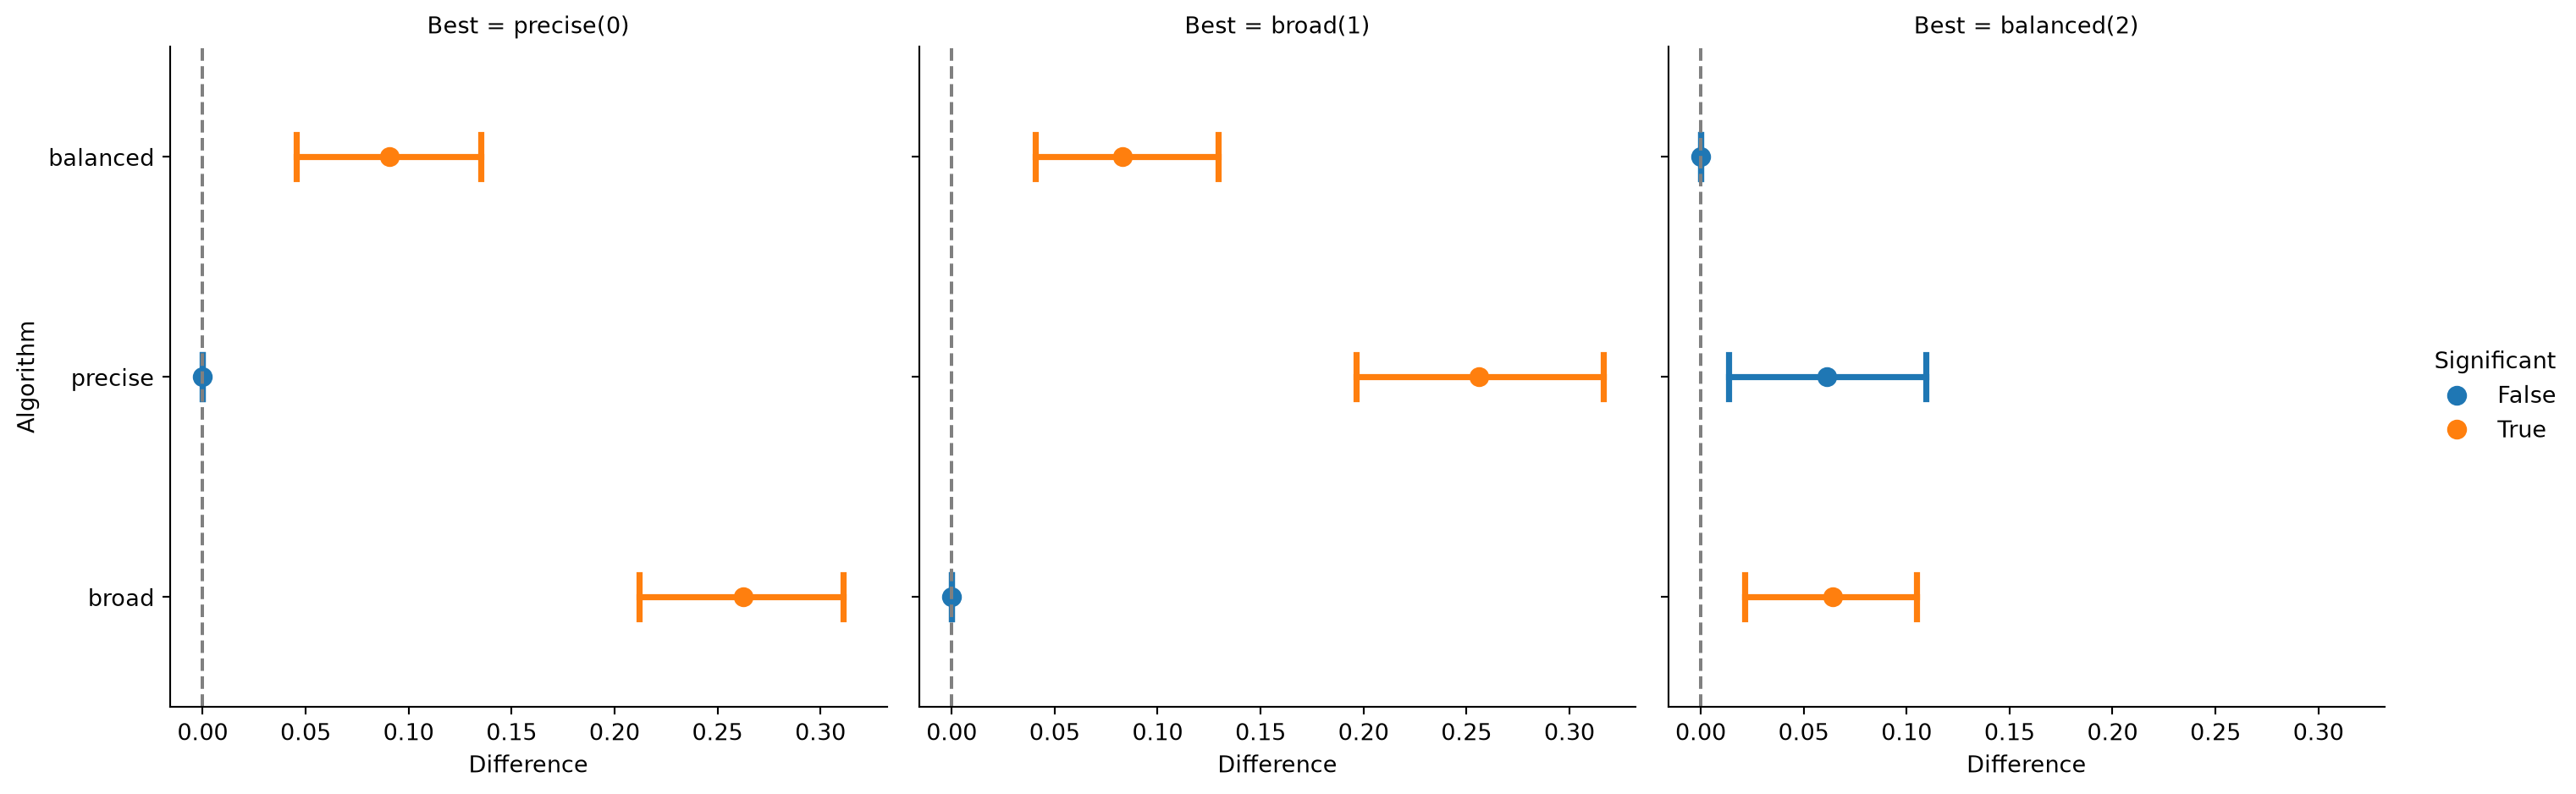

In [9]:
diff.plot(correction='bonferroni')

[scikit-learn Users](sklearn_users.ipynb) and [Competition Organizers](competition_organizers.ipynb) show this same workflow with a single performance measure, comparing a handful of estimators or ranking many competition submissions against a shared gold standard.